Model Accuracy: 1.00


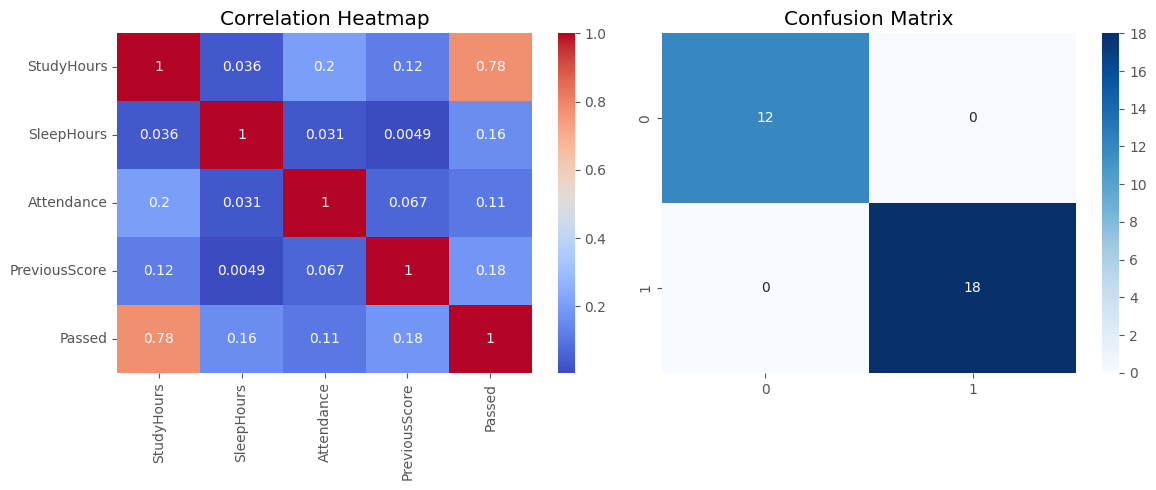

In [ ]:
# practice Numpy + polars + sklearn + matpoltlib +seaborn
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.preprocessing import StandardScaler

np.random.seed(42)
n = 150

df = pl.DataFrame({
    "StudyHours": np.random.uniform(1, 10, n),
    "SleepHours": np.random.uniform(4, 9, n),
    "Attendance": np.random.randint(60, 100, n),
    "PreviousScore": np.random.randint(40, 95, n)
})

df = df.with_columns([
    pl.when(pl.col("StudyHours") < 2).then(None).otherwise(pl.col("StudyHours")).alias("StudyHours"),
    pl.when(pl.col("PreviousScore") < 50).then(None).otherwise(pl.col("PreviousScore")).alias("PreviousScore")
])

df = df.with_columns([
    pl.col("StudyHours").fill_null(df["StudyHours"].mean()),
    pl.col("PreviousScore").fill_null(df["PreviousScore"].mean())
])

df = df.with_columns(
    ((pl.col("StudyHours") * 0.5 + pl.col("SleepHours") * 0.2 + pl.col("PreviousScore") * 0.02) > 5).cast(pl.Int64).alias("Passed")
)

X = df.select(["StudyHours", "SleepHours", "Attendance", "PreviousScore"]).to_numpy()
y = df.select("Passed").to_numpy().ravel()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

model = LogisticRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

acc = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

print(f"Model Accuracy: {acc:.2f}")

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.heatmap(df.to_pandas().corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")

plt.subplot(1, 2, 2)
sns.heatmap(cm, annot=True, fmt='d', cmap="Blues")
plt.title("Confusion Matrix")

plt.tight_layout()
plt.show()

In [4]:
import numpy as np
from sklearn.linear_model import LogisticRegression
X = np.array([[1], [2], [3], [4], [5]])
y = np.array([0, 0, 0, 1, 1])
model = LogisticRegression()
model.fit(X, y)
predictions = model.predict(X)
print(predictions)

[0 0 0 1 1]


In [ ]:
import polars as pl
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report

n = 500
df = pl.DataFrame({
    "Usage_Hours": np.random.uniform(10, 100, n),
    "Support_Tickets": np.random.randint(0, 10, n),
    "Monthly_Charges": np.random.uniform(200, 2000, n),
    "Churn": np.random.randint(0, 2, n)
})

X = df.select(["Usage_Hours", "Support_Tickets", "Monthly_Charges"]).to_numpy()
y = df.select("Churn").to_numpy().ravel()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

model = LogisticRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Model Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print(df)

Model Accuracy: 0.51

Classification Report:
               precision    recall  f1-score   support

           0       0.54      0.40      0.46        52
           1       0.49      0.62      0.55        48

    accuracy                           0.51       100
   macro avg       0.52      0.51      0.51       100
weighted avg       0.52      0.51      0.50       100

